# Federated Learning with Bottom 10 Force Accept Strategy
This notebook implements federated learning with forced weight acceptance for struggling clients:
- 100 clients, each with 100 samples (10 per class)
- 100 communication rounds, 10 local epochs per round
- **Strategy**: 
  - **Every round**: All 100 clients train normally with their local data
  - **On 10th rounds (10, 20, 30, ...)**: 
    - Identify bottom 10 clients by test accuracy
    - Bottom 10: **Force accept** new weights (no weight rejection)
    - Top 90: Apply normal adaptive weight rejection
  - **On other rounds**: All 100 clients apply normal weight rejection
  - **Always**: All 100 clients participate in federated averaging
- Common test dataset of 500 samples

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

import os
from tqdm import tqdm

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


In [2]:
# GPU Configuration
print("=" * 60)
print("GPU CONFIGURATION")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU detected and configured")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("⚠ No GPU detected - Running on CPU")
print("=" * 60 + "\n")

GPU CONFIGURATION
TensorFlow version: 2.10.0
Num GPUs Available: 1
✓ GPU detected and configured



## Configuration

In [3]:
# Federated Learning Configuration
NUM_CLIENTS = 100
NUM_ROUNDS = 200
LOCAL_EPOCHS = 10
BATCH_SIZE = 32
NUM_BOTTOM_CLIENTS = 10  # Number of bottom clients to force accept on 10th rounds

# Directories
DATA_DIR = 'mnist_100_clients'
RESULTS_DIR = 'results_bottom10_force_accept'
os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 60)
print("FEDERATED LEARNING - BOTTOM 10 FORCE ACCEPT")
print("=" * 60)
print(f"Number of Clients: {NUM_CLIENTS}")
print(f"Communication Rounds: {NUM_ROUNDS}")
print(f"Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Strategy: Force accept bottom {NUM_BOTTOM_CLIENTS} on 10th rounds")
print(f"  - Every round: All 100 clients train normally")
print(f"  - 10th rounds (10, 20, 30...): Bottom {NUM_BOTTOM_CLIENTS} force accept new weights")
print(f"  - Other rounds: All clients apply normal weight rejection")
print(f"  - Always: All 100 clients participate in federated averaging")
print(f"Data Directory: {DATA_DIR}/")
print(f"Results Directory: {RESULTS_DIR}/")
print("=" * 60 + "\n")

FEDERATED LEARNING - BOTTOM 10 FORCE ACCEPT
Number of Clients: 100
Communication Rounds: 200
Local Epochs per Round: 10
Batch Size: 32
Strategy: Force accept bottom 10 on 10th rounds
  - Every round: All 100 clients train normally
  - 10th rounds (10, 20, 30...): Bottom 10 force accept new weights
  - Other rounds: All clients apply normal weight rejection
  - Always: All 100 clients participate in federated averaging
Data Directory: mnist_100_clients/
Results Directory: results_bottom10_force_accept/



## Load Data

In [4]:
# Load test data (common for all clients)
print("Loading common test dataset...")
test_file = os.path.join(DATA_DIR, 'test_500_samples.npz')
test_data = np.load(test_file)

x_test = test_data['x'] / 255.0
y_test = test_data['y']
x_test = x_test.reshape(len(x_test), 28*28)

print(f"✓ Test data loaded: {x_test.shape}")
print(f"  Labels shape: {y_test.shape}")

Loading common test dataset...
✓ Test data loaded: (500, 784)
  Labels shape: (500,)


In [5]:
# Load all client data
print(f"\nLoading data for {NUM_CLIENTS} clients...")
client_data = []

for client_id in range(1, NUM_CLIENTS + 1):
    client_file = os.path.join(DATA_DIR, f'client_{client_id}.npz')
    data = np.load(client_file)
    
    x_client = data['x'] / 255.0
    y_client = data['y']
    x_client = x_client.reshape(len(x_client), 28*28)
    
    client_data.append({
        'x_train': x_client,
        'y_train': y_client,
        'x_test': x_test,
        'y_test': y_test
    })
    
    if client_id % 20 == 0:
        print(f"  Loaded {client_id}/{NUM_CLIENTS} clients")

print(f"\n✓ All {NUM_CLIENTS} clients loaded successfully")
print(f"  Each client has {len(client_data[0]['x_train'])} training samples")
print(f"  Common test set: {len(x_test)} samples")


Loading data for 100 clients...
  Loaded 20/100 clients
  Loaded 40/100 clients
  Loaded 60/100 clients
  Loaded 80/100 clients
  Loaded 100/100 clients

✓ All 100 clients loaded successfully
  Each client has 100 training samples
  Common test set: 500 samples


## Model Architecture

In [6]:
# Define model (same architecture as before)
def create_model():
    """Lightweight model optimized for small datasets"""
    model = keras.Sequential([
        keras.layers.Dense(64, input_shape=(784,), activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation="softmax")
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Test model creation
print("Testing model architecture...")
test_model = create_model()
test_model.summary()
print("\n✓ Model architecture validated")

Testing model architecture...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________

✓ Model architecture 

## Federated Learning Functions

In [7]:
# Federated Averaging function
def federated_averaging(weights_list):
    """Average weights from all clients (FedAvg)"""
    avg_weights = []
    for weights_tuple in zip(*weights_list):
        avg_weights.append(np.mean(weights_tuple, axis=0))
    return avg_weights

print("✓ Federated averaging function defined")

✓ Federated averaging function defined


## Federated Training with Bottom 10 Force Accept Strategy

In [8]:
# Initialize global model
print("\n" + "=" * 60)
print("INITIALIZING FEDERATED LEARNING")
print("=" * 60)

global_model = create_model()
global_weights = global_model.get_weights()

# Tracking arrays
client_train_acc_history = [[] for _ in range(NUM_CLIENTS)]  # Training accuracy per client per round
client_test_acc_history = [[] for _ in range(NUM_CLIENTS)]   # Test accuracy per client per round
client_best_weights = [None for _ in range(NUM_CLIENTS)]      # Best weights for each client
client_best_test_acc = [0.0 for _ in range(NUM_CLIENTS)]      # Best test accuracy for each client
client_best_train_acc = [0.0 for _ in range(NUM_CLIENTS)]     # Best training accuracy for each client
client_rejections = [[] for _ in range(NUM_CLIENTS)]          # Track status per round:
                                                               # 0=accepted, 1=rejected, 
                                                               # 2=bottom10_forced_accept
bottom_10_clients = []                                         # Current bottom 10 clients

print("✓ Global model initialized")
print("✓ Tracking arrays created")
print("✓ Bottom 10 force accept mechanism ready")


INITIALIZING FEDERATED LEARNING
✓ Global model initialized
✓ Tracking arrays created
✓ Bottom 10 force accept mechanism ready


In [ ]:
# Main federated training loop with bottom 10 force accept
print("\n" + "=" * 60)
print("STARTING FEDERATED TRAINING - BOTTOM 10 FORCE ACCEPT")
print("=" * 60 + "\n")

for round_num in tqdm(range(NUM_ROUNDS), desc="Communication Rounds", unit="round"):
    print(f"\n{'='*60}")
    print(f"ROUND {round_num + 1}/{NUM_ROUNDS}")
    print(f"{'='*60}")
    
    # Check if this is a 10th round (10, 20, 30, ...)
    is_10th_round = (round_num + 1) % 10 == 0 and round_num >= 9
    
    local_weights = []
    round_train_accs = [0.0] * NUM_CLIENTS
    round_test_accs = [0.0] * NUM_CLIENTS
    round_rejections = 0
    round_acceptances = 0
    round_forced_accepts = 0
    trained_weights_for_eval = []
    
    # STEP 1: ALL 100 CLIENTS TRAIN with global weights
    for client_id in tqdm(range(NUM_CLIENTS), desc=f"Training All Clients (Round {round_num + 1})", 
                         unit="client", leave=False):
        
        client_model = create_model()
        client_model.set_weights(global_weights)
        
        x_train = client_data[client_id]['x_train']
        y_train = client_data[client_id]['y_train']
        x_test = client_data[client_id]['x_test']
        y_test = client_data[client_id]['y_test']
        
        # Train locally
        history = client_model.fit(
            x_train, y_train,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
        
        train_acc = history.history['accuracy'][-1]
        _, test_acc = client_model.evaluate(x_test, y_test, verbose=0)
        
        trained_weights_for_eval.append((client_id, test_acc, train_acc, [w.copy() for w in client_model.get_weights()]))
        round_train_accs[client_id] = train_acc
        round_test_accs[client_id] = test_acc
    
    # STEP 2: IDENTIFY BOTTOM 10 BASED ON TEST ACCURACY (on 10th rounds)
    if is_10th_round:
        trained_weights_for_eval.sort(key=lambda x: x[1])
        bottom_10_clients = [client_id for client_id, _, _, _ in trained_weights_for_eval[:10]]
        print(f"\n   🔍 10th Round - Identifying Bottom 10 clients")
        print(f"   Bottom 10 clients: {[c+1 for c in bottom_10_clients]}")
        print(f"   Bottom 10 test accs: {[f'{x[1]*100:.1f}%' for x in trained_weights_for_eval[:10]]}")
    
    # STEP 3: APPLY WEIGHT REJECTION (Different for bottom 10 on 10th rounds)
    for client_id, test_acc, train_acc, trained_weights in trained_weights_for_eval:
        is_bottom_10 = (client_id in bottom_10_clients) and is_10th_round
        
        if is_bottom_10:
            # FORCE ACCEPT new weights for bottom 10 on 10th rounds
            client_best_weights[client_id] = trained_weights
            client_best_test_acc[client_id] = test_acc
            client_best_train_acc[client_id] = train_acc
            client_rejections[client_id].append(2)  # Bottom 10 forced accept
            round_forced_accepts += 1
            
        else:
            # NORMAL WEIGHT REJECTION for all others
            if test_acc > client_best_test_acc[client_id]:
                # Accept new weights
                client_best_weights[client_id] = trained_weights
                client_best_test_acc[client_id] = test_acc
                client_best_train_acc[client_id] = train_acc
                client_rejections[client_id].append(0)  # Accepted
                round_acceptances += 1
            else:
                # Reject new weights
                if client_best_weights[client_id] is None:
                    # First round - accept anyway
                    client_best_weights[client_id] = trained_weights
                    client_best_test_acc[client_id] = test_acc
                    client_best_train_acc[client_id] = train_acc
                    client_rejections[client_id].append(0)
                    round_acceptances += 1
                else:
                    # Keep previous best
                    client_rejections[client_id].append(1)  # Rejected
                    round_rejections += 1
                    test_acc = client_best_test_acc[client_id]
                    train_acc = client_best_train_acc[client_id]
        
        # ALL clients included in averaging
        local_weights.append(client_best_weights[client_id])
        
        # Store accuracies
        client_train_acc_history[client_id].append(train_acc)
        client_test_acc_history[client_id].append(test_acc)
        round_train_accs[client_id] = train_acc
        round_test_accs[client_id] = test_acc
    
    # STEP 4: Federated averaging
    global_weights = federated_averaging(local_weights)
    global_model.set_weights(global_weights)
    
    # Round summary
    avg_train_acc = np.mean(round_train_accs) * 100
    avg_test_acc = np.mean(round_test_accs) * 100
    min_test_acc = np.min(round_test_accs) * 100
    max_test_acc = np.max(round_test_accs) * 100
    
    print(f"\n📊 Round {round_num + 1} Summary:")
    print(f"   Avg Training Accuracy: {avg_train_acc:.2f}%")
    print(f"   Avg Test Accuracy: {avg_test_acc:.2f}%")
    print(f"   Test Accuracy Range: [{min_test_acc:.2f}%, {max_test_acc:.2f}%]")
    print(f"   All 100 clients in averaging")
    
    if is_10th_round:
        print(f"   🔓 10th Round: Bottom {NUM_BOTTOM_CLIENTS} FORCE ACCEPTED: {round_forced_accepts}")
        print(f"   Top {NUM_CLIENTS - NUM_BOTTOM_CLIENTS}: Normal rejection applied")
    
    print(f"   Weights Accepted: {round_acceptances}")
    print(f"   Weights Rejected: {round_rejections}")
    if round_forced_accepts > 0:
        print(f"   Weights Force Accepted: {round_forced_accepts}")

print("\n" + "="*60)
print("FEDERATED TRAINING COMPLETE!")
print("="*60 + "\n")


STARTING FEDERATED TRAINING - BOTTOM 10 FORCE ACCEPT



Communication Rounds:   0%|          | 0/200 [00:00<?, ?round/s]


ROUND 1/200


Communication Rounds:   0%|          | 1/200 [00:45<2:32:12, 45.89s/round]


📊 Round 1 Summary:
   Avg Training Accuracy: 58.25%
   Avg Test Accuracy: 58.47%
   Test Accuracy Range: [45.60%, 67.20%]
   All 100 clients in averaging
   Weights Accepted: 100
   Weights Rejected: 0

ROUND 2/200


...


   🔍 10th Round - Identifying Bottom 10 clients
   Bottom 10 clients: [92, 43, 86, 15, 17, 76, 97, 19, 21, 34]
   Bottom 10 test accs: ['87.8%', '88.2%', '88.2%', '88.4%', '88.4%', '88.4%', '88.4%', '88.6%', '88.6%', '88.6%']

📊 Round 180 Summary:
   Avg Training Accuracy: 96.65%
   Avg Test Accuracy: 90.94%
   Test Accuracy Range: [87.80%, 93.00%]
   All 100 clients in averaging
   🔓 10th Round: Bottom 10 FORCE ACCEPTED: 10
   Top 90: Normal rejection applied
   Weights Accepted: 3
   Weights Rejected: 87
   Weights Force Accepted: 10

ROUND 181/200


Communication Rounds:  90%|█████████ | 181/200 [2:24:12<16:54, 53.41s/round]


📊 Round 181 Summary:
   Avg Training Accuracy: 96.63%
   Avg Test Accuracy: 91.04%
   Test Accuracy Range: [88.40%, 93.00%]
   All 100 clients in averaging
   Weights Accepted: 12
   Weights Rejected: 88

ROUND 182/200


Communication Rounds:  91%|█████████ | 182/200 [2:25:06<16:05, 53.62s/round]


📊 Round 182 Summary:
   Avg Training Accuracy: 96.59%
   Avg Test Accuracy: 91.07%
   Test Accuracy Range: [88.40%, 93.00%]
   All 100 clients in averaging
   Weights Accepted: 6
   Weights Rejected: 94

ROUND 183/200


In [ ]:
# Calculate final accuracies and statistics
final_train_accs = [client_train_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]
final_test_accs = [client_test_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]

avg_final_train = np.mean(final_train_accs)
avg_final_test = np.mean(final_test_accs)

# Calculate statistics (0=accepted, 1=rejected, 2=bottom10_forced_accept)
total_rejections_per_client = []
total_forced_accepts_per_client = []
total_acceptances_per_client = []

for client_id in range(NUM_CLIENTS):
    rejections = sum(1 for status in client_rejections[client_id] if status == 1)
    forced_accepts = sum(1 for status in client_rejections[client_id] if status == 2)
    acceptances = sum(1 for status in client_rejections[client_id] if status == 0)
    
    total_rejections_per_client.append(rejections)
    total_forced_accepts_per_client.append(forced_accepts)
    total_acceptances_per_client.append(acceptances)

avg_rejections = np.mean(total_rejections_per_client)
avg_forced_accepts = np.mean(total_forced_accepts_per_client)
total_rejections = sum(total_rejections_per_client)
total_forced_accepts = sum(total_forced_accepts_per_client)
num_10th_rounds = NUM_ROUNDS // 10

# Identify which clients were in bottom 10 at the end
if len(bottom_10_clients) > 0:
    final_bottom_10 = bottom_10_clients
else:
    final_bottom_10 = []

print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"Average Final Training Accuracy: {avg_final_train:.2f}%")
print(f"Average Final Test Accuracy: {avg_final_test:.2f}%")
print(f"Training Accuracy Range: [{np.min(final_train_accs):.2f}%, {np.max(final_train_accs):.2f}%]")
print(f"Test Accuracy Range: [{np.min(final_test_accs):.2f}%, {np.max(final_test_accs):.2f}%]")
print(f"\nFinal Bottom 10 Clients: {[c+1 for c in final_bottom_10]}")
print(f"\nWeight Update Statistics:")
print(f"  Total Acceptances: {sum(total_acceptances_per_client)}")
print(f"  Total Rejections: {total_rejections}")
print(f"  Total Forced Accepts (Bottom 10 on 10th rounds): {total_forced_accepts}")
print(f"  Number of 10th Rounds: {num_10th_rounds}")
print(f"  Rejection Rate: {total_rejections / (sum(total_acceptances_per_client) + total_rejections + total_forced_accepts) * 100:.2f}%")
print(f"  Avg Forced Accepts per Client: {avg_forced_accepts:.2f}/{num_10th_rounds} (10th rounds)")
print("=" * 60)

FINAL RESULTS
Average Final Training Accuracy: 95.29%
Average Final Test Accuracy: 89.86%
Training Accuracy Range: [90.00%, 99.00%]
Test Accuracy Range: [85.80%, 91.80%]

Final Bottom 10 Clients: [76, 19, 30, 87, 40, 33, 37, 50, 53, 60]

Weight Update Statistics:
  Total Acceptances: 1662
  Total Rejections: 8238
  Total Forced Accepts (Bottom 10 on 10th rounds): 100
  Number of 10th Rounds: 10
  Rejection Rate: 82.38%
  Avg Forced Accepts per Client: 1.00/10 (10th rounds)


In [1]:
# Save complete ranking tables to CSV files
print("\nSaving detailed ranking tables to CSV files...")

for round_num, df in all_tables:
    csv_filename = os.path.join(RESULTS_DIR, f'client_rankings_round_{round_num}.csv')
    df.to_csv(csv_filename, index=False)
    print(f"✓ Saved: {csv_filename}")

# Save a combined summary file
print("\nCreating combined summary file...")
summary_file = os.path.join(RESULTS_DIR, 'client_rankings_summary.txt')

with open(summary_file, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("CLIENT RANKING BY TEST ACCURACY AT KEY ROUNDS\n")
    f.write("=" * 80 + "\n\n")
    
    for round_num, df in all_tables:
        f.write(f"\n{'='*80}\n")
        f.write(f"ROUND {round_num} - COMPLETE RANKING (All 100 Clients)\n")
        f.write(f"{'='*80}\n\n")
        f.write(df.to_string(index=False))
        f.write(f"\n\nRound {round_num} Statistics:\n")
        f.write(f"  Average Test Accuracy: {df['Test_Acc'].mean():.2f}%\n")
        f.write(f"  Test Accuracy Range: [{df['Test_Acc'].min():.2f}%, {df['Test_Acc'].max():.2f}%]\n")
        f.write(f"  Standard Deviation: {df['Test_Acc'].std():.2f}%\n")
        f.write(f"  Total Forced Accepts: {df['Forced_Accept'].sum()}\n")
        f.write("\n")

print(f"✓ Saved: {summary_file}")

print("\n" + "="*80)
print("ALL RANKING TABLES SAVED SUCCESSFULLY")
print("="*80)


Saving detailed ranking tables to CSV files...


NameError: name 'all_tables' is not defined

In [2]:
# Analyze client performance at specific rounds
import pandas as pd

# Define rounds to analyze
analysis_rounds = [10, 30, 50, 100, 150, 200]

# Create detailed tables for each analysis round
print("=" * 80)
print("CLIENT RANKING BY TEST ACCURACY AT KEY ROUNDS")
print("=" * 80)

# Store all tables for saving to file
all_tables = []

for round_num in analysis_rounds:
    round_idx = round_num - 1  # Convert to 0-based index
    
    print(f"\n{'='*80}")
    print(f"ROUND {round_num} - CLIENT RANKINGS")
    print(f"{'='*80}\n")
    
    # Collect data for all clients at this round
    client_data_list = []
    for client_id in range(NUM_CLIENTS):
        test_acc = client_test_acc_history[client_id][round_idx] * 100
        train_acc = client_train_acc_history[client_id][round_idx] * 100
        
        # Count rejections, acceptances, and forced accepts up to this round
        rejections_so_far = sum(1 for status in client_rejections[client_id][:round_num] if status == 1)
        forced_accepts_so_far = sum(1 for status in client_rejections[client_id][:round_num] if status == 2)
        acceptances_so_far = sum(1 for status in client_rejections[client_id][:round_num] if status == 0)
        
        client_data_list.append({
            'Client_ID': client_id + 1,
            'Test_Acc': test_acc,
            'Train_Acc': train_acc,
            'Accepted': acceptances_so_far,
            'Rejected': rejections_so_far,
            'Forced_Accept': forced_accepts_so_far
        })
    
    # Sort by test accuracy (descending)
    client_data_list.sort(key=lambda x: x['Test_Acc'], reverse=True)
    
    # Add rank
    for rank, client_data in enumerate(client_data_list, 1):
        client_data['Rank'] = rank
    
    # Create DataFrame
    df = pd.DataFrame(client_data_list)
    df = df[['Rank', 'Client_ID', 'Test_Acc', 'Train_Acc', 'Accepted', 'Rejected', 'Forced_Accept']]
    
    # Store table
    all_tables.append((round_num, df))
    
    # Display top 10, middle 10, and bottom 10
    print("🏆 TOP 10 CLIENTS:")
    print(df.head(10).to_string(index=False))
    
    print(f"\n📊 MIDDLE 10 CLIENTS (Ranks 46-55):")
    print(df.iloc[45:55].to_string(index=False))
    
    print(f"\n⚠️  BOTTOM 10 CLIENTS:")
    print(df.tail(10).to_string(index=False))
    
    # Summary statistics
    print(f"\n📈 Round {round_num} Summary:")
    print(f"   Average Test Accuracy: {df['Test_Acc'].mean():.2f}%")
    print(f"   Test Accuracy Range: [{df['Test_Acc'].min():.2f}%, {df['Test_Acc'].max():.2f}%]")
    print(f"   Std Dev: {df['Test_Acc'].std():.2f}%")
    print(f"   Total Forced Accepts: {df['Forced_Accept'].sum()}")

print("\n" + "="*80)
print("CLIENT RANKING ANALYSIS COMPLETE")
print("="*80)

CLIENT RANKING BY TEST ACCURACY AT KEY ROUNDS

ROUND 10 - CLIENT RANKINGS



NameError: name 'NUM_CLIENTS' is not defined

## Client Performance Analysis at Key Rounds

## Visualization

Creating training accuracy plot for 100 clients...
✓ Saved: results_bottom10_force_accept\training_accuracy_bottom10_force_accept.png


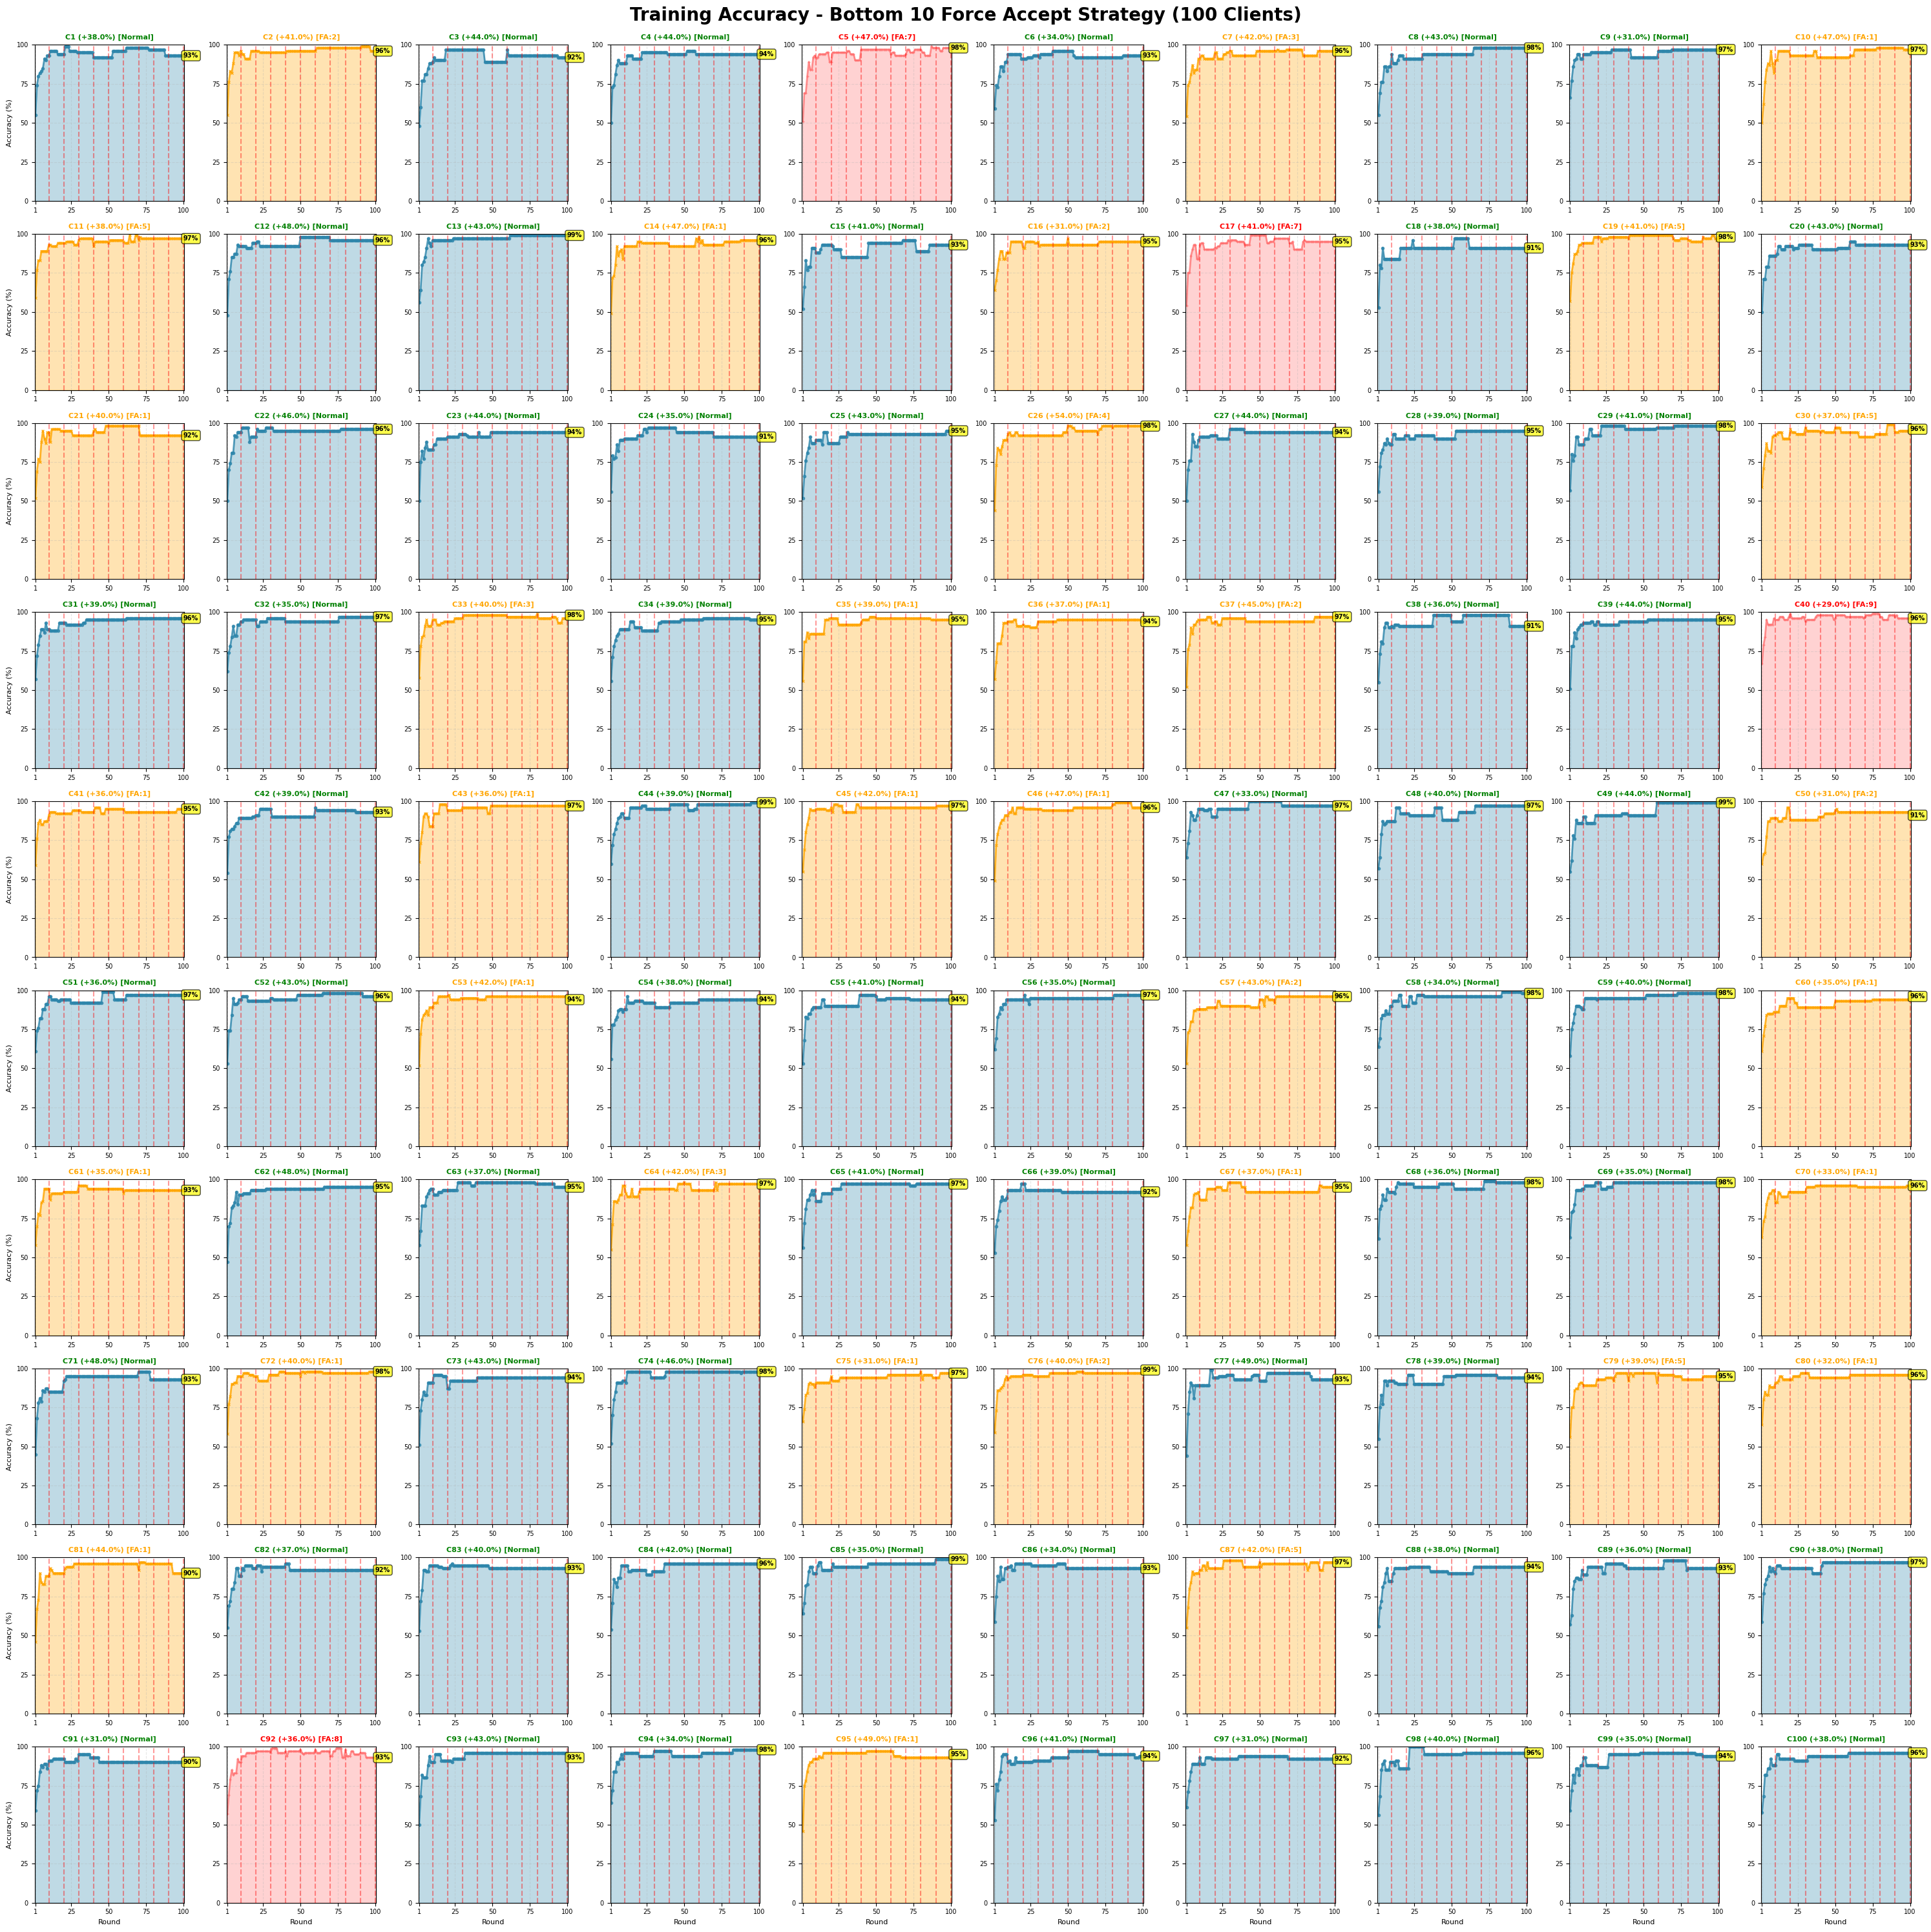

In [ ]:
# Plot 1: Individual Training Accuracy for Each Client
print("Creating training accuracy plot for 100 clients...")

fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Training Accuracy - Bottom 10 Force Accept Strategy (100 Clients)', fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    train_accs = [acc * 100 for acc in client_train_acc_history[client_id]]
    final_acc = train_accs[-1]
    improvement = final_acc - train_accs[0]
    forced_accepts_count = total_forced_accepts_per_client[client_id]
    
    # Different styling based on forced accepts
    if forced_accepts_count > NUM_ROUNDS // 20:  # More than 5% of rounds
        color = '#FF6B6B'  # Red for clients who were often in bottom 10
        alpha = 0.7
        marker = '+'
        title_color = 'red'
        status = f'FA:{forced_accepts_count}'
    elif forced_accepts_count > 0:
        color = '#FFA500'  # Orange for some forced accepts
        alpha = 0.8
        marker = 'x'
        title_color = 'orange'
        status = f'FA:{forced_accepts_count}'
    else:
        color = '#2E86AB'  # Blue for no forced accepts
        alpha = 0.8
        marker = 'o'
        title_color = 'green'
        status = 'Normal'
    
    ax.plot(rounds, train_accs, marker=marker, linewidth=2, markersize=3, color=color, alpha=alpha)
    ax.fill_between(rounds, train_accs, alpha=0.3, color=color)
    
    # Add vertical lines at every 10th round
    for force_round in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
        if force_round <= NUM_ROUNDS:
            ax.axvline(x=force_round, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
    
    ax.set_title(f'C{client_id+1} ({improvement:+.1f}%) [{status}]', 
                fontsize=8, fontweight='bold', color=title_color)
    
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=7, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks([1, 25, 50, 75, 100])
    ax.set_xticklabels(['1', '25', '50', '75', '100'], fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
train_plot_path = os.path.join(RESULTS_DIR, 'training_accuracy_bottom10_force_accept.png')
plt.savefig(train_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {train_plot_path}")
plt.show()

Creating test accuracy plot for 100 clients...
✓ Saved: results_bottom10_force_accept\test_accuracy_bottom10_force_accept.png


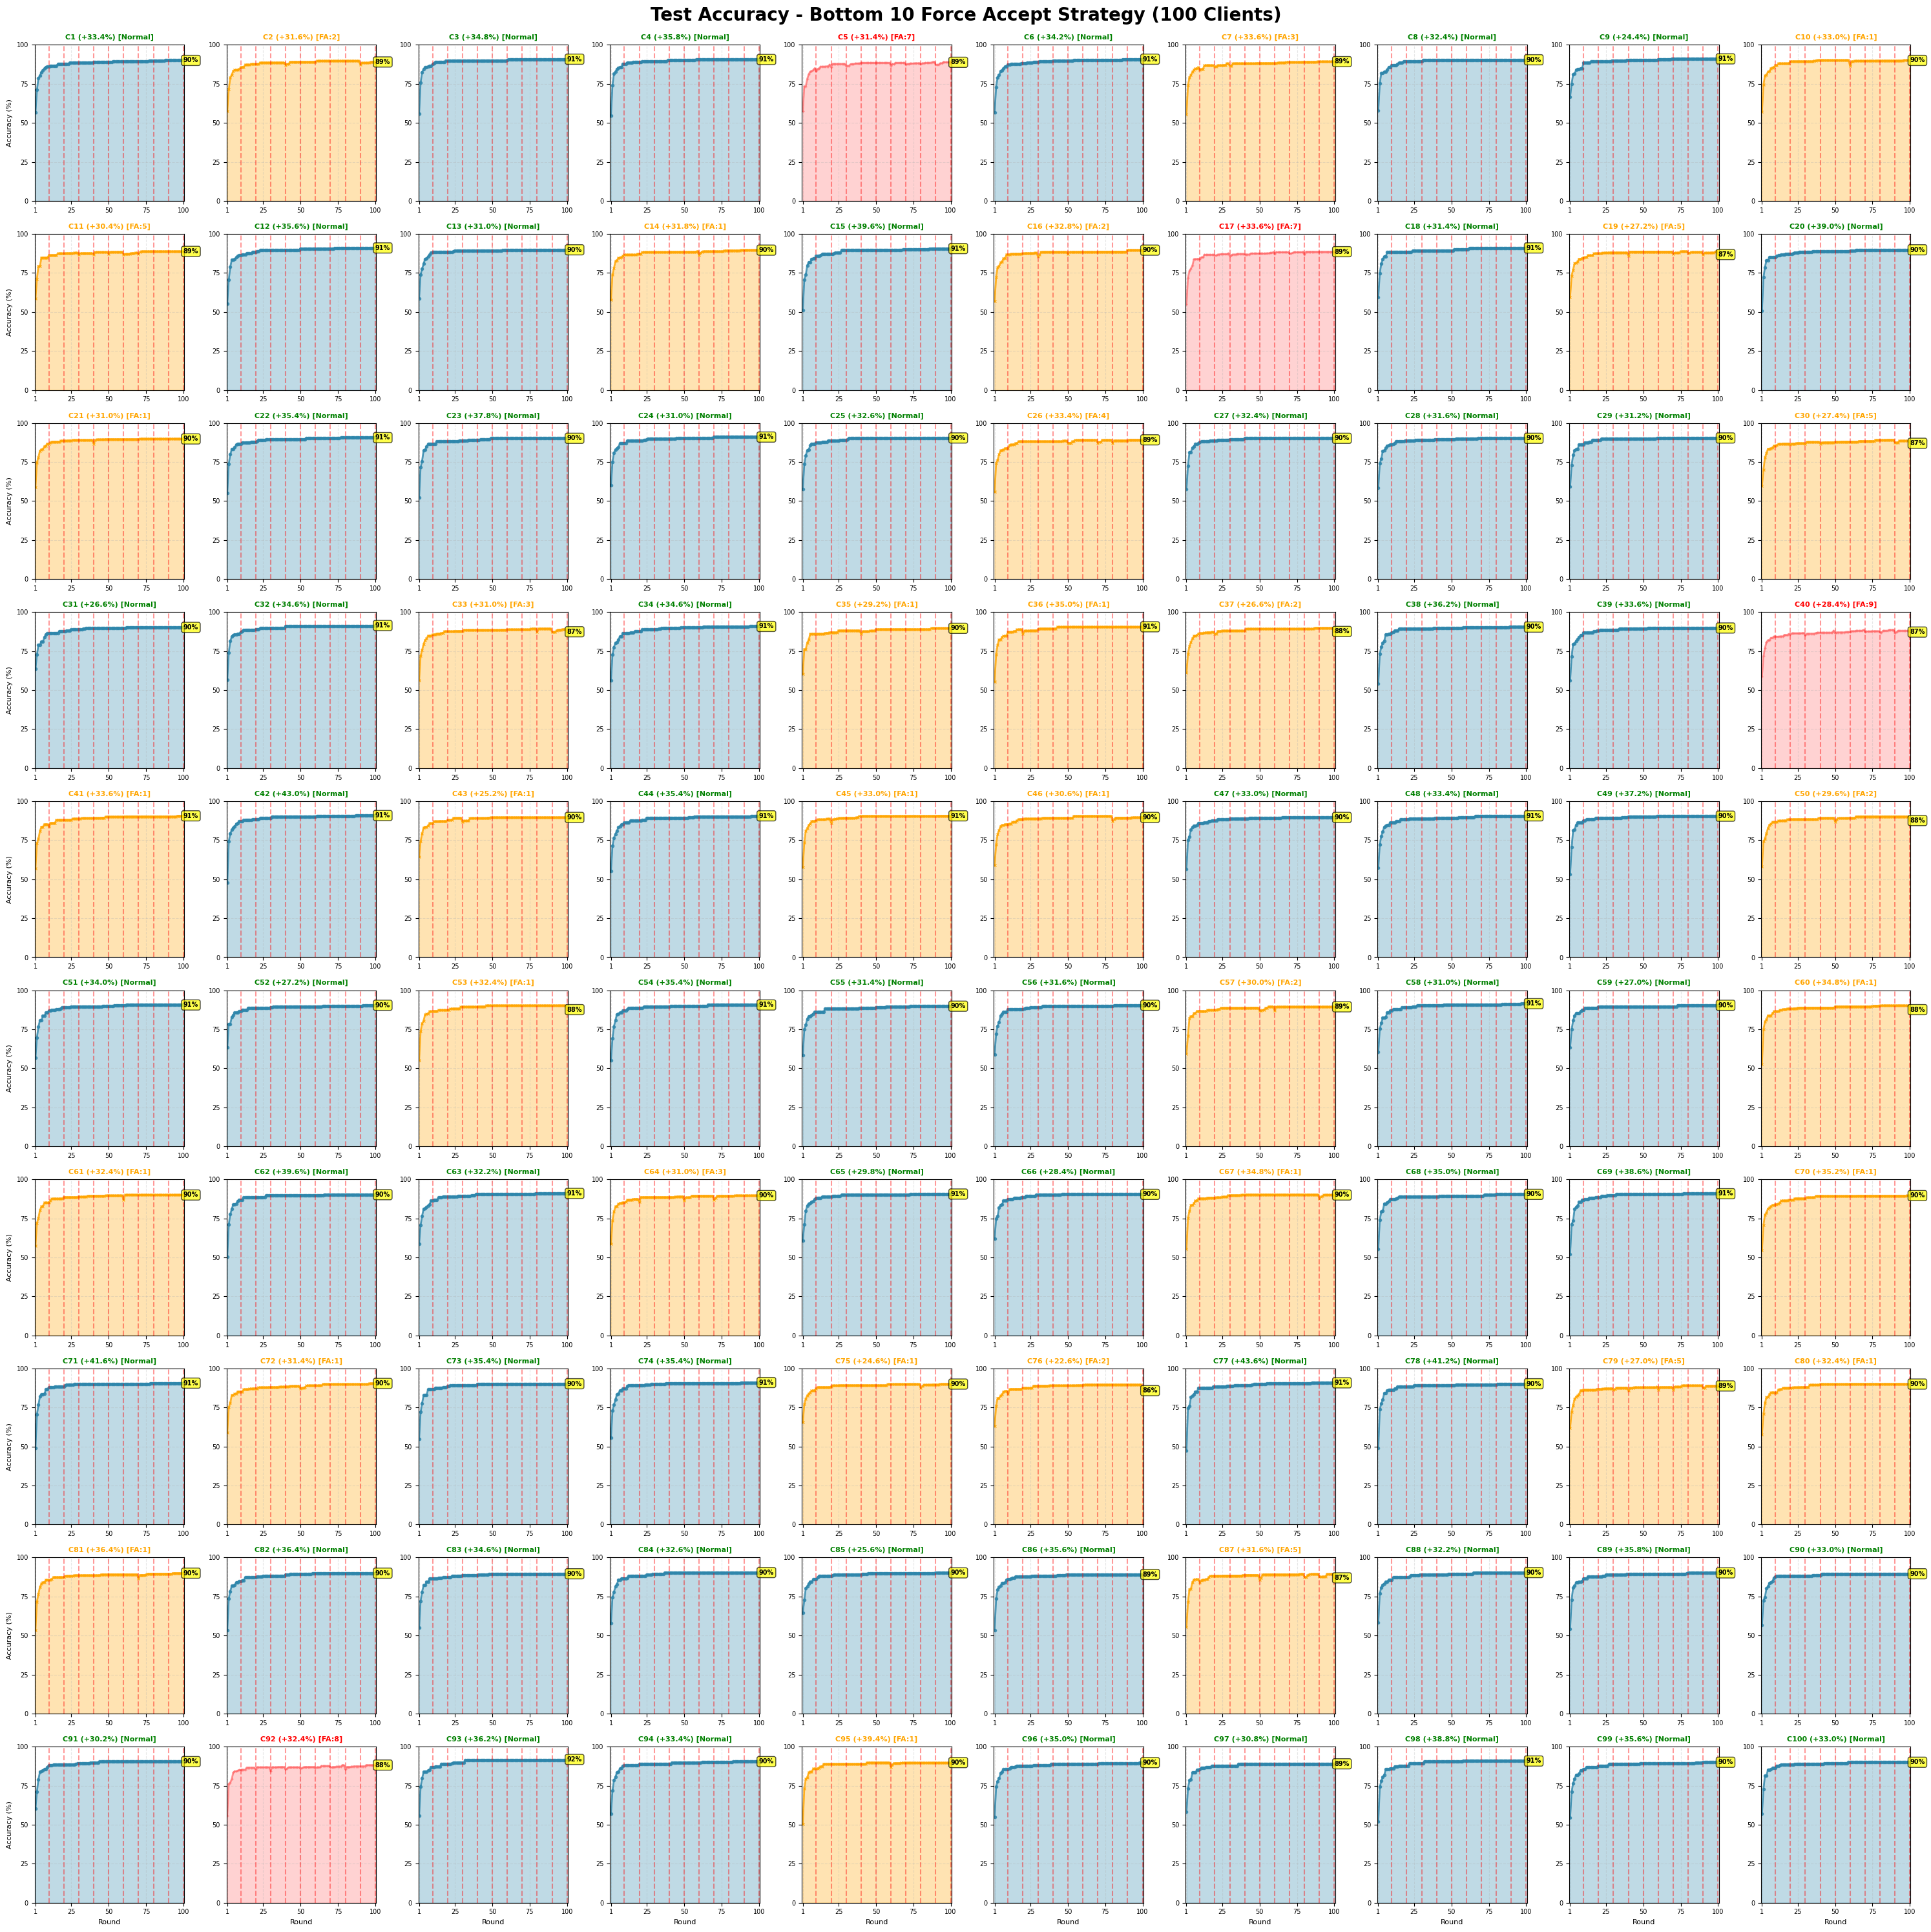

In [ ]:
# Plot 2: Individual Test Accuracy for Each Client
print("Creating test accuracy plot for 100 clients...")

fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Test Accuracy - Bottom 10 Force Accept Strategy (100 Clients)', fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    test_accs = [acc * 100 for acc in client_test_acc_history[client_id]]
    final_acc = test_accs[-1]
    improvement = final_acc - test_accs[0]
    forced_accepts_count = total_forced_accepts_per_client[client_id]
    
    # Different styling based on forced accepts
    if forced_accepts_count > NUM_ROUNDS // 20:
        color = '#FF6B6B'
        alpha = 0.7
        marker = '+'
        title_color = 'red'
        status = f'FA:{forced_accepts_count}'
    elif forced_accepts_count > 0:
        color = '#FFA500'
        alpha = 0.8
        marker = 'x'
        title_color = 'orange'
        status = f'FA:{forced_accepts_count}'
    else:
        color = '#2E86AB'
        alpha = 0.8
        marker = 'o'
        title_color = 'green'
        status = 'Normal'
    
    ax.plot(rounds, test_accs, marker=marker, linewidth=2, markersize=3, color=color, alpha=alpha)
    ax.fill_between(rounds, test_accs, alpha=0.3, color=color)
    
    # Add vertical lines at every 10th round
    for force_round in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
        if force_round <= NUM_ROUNDS:
            ax.axvline(x=force_round, color='red', linestyle='--', alpha=0.4, linewidth=1.5)
    
    ax.set_title(f'C{client_id+1} ({improvement:+.1f}%) [{status}]', 
                fontsize=8, fontweight='bold', color=title_color)
    
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=7, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks([1, 25, 50, 75, 100])
    ax.set_xticklabels(['1', '25', '50', '75', '100'], fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
test_plot_path = os.path.join(RESULTS_DIR, 'test_accuracy_bottom10_force_accept.png')
plt.savefig(test_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {test_plot_path}")
plt.show()

Creating average accuracy plot...
✓ Saved: results_bottom10_force_accept\average_accuracy_bottom10_force_accept.png


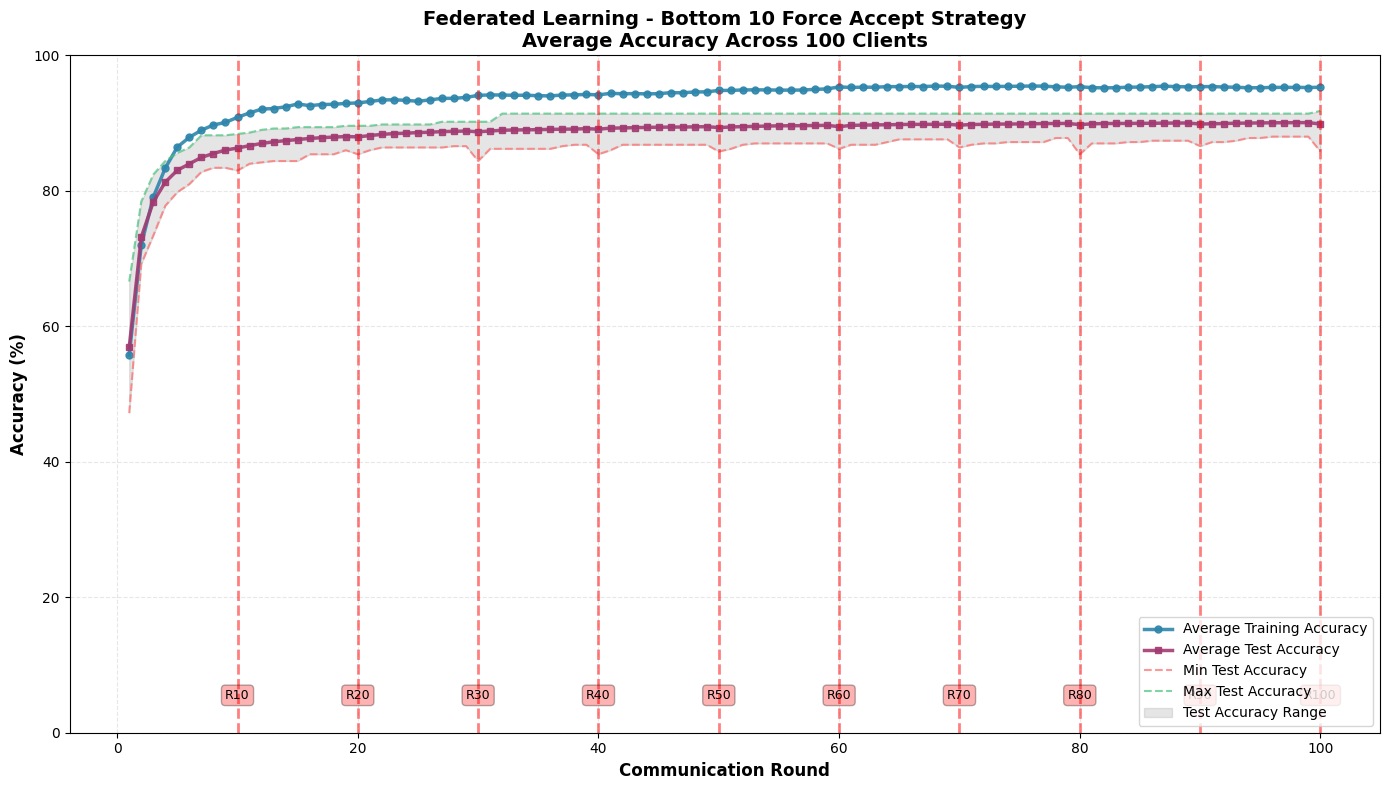

In [ ]:
# Plot 3: Average Accuracy Over Rounds (Train and Test)
print("Creating average accuracy plot...")

rounds = range(1, NUM_ROUNDS + 1)
avg_train_per_round = [np.mean([client_train_acc_history[i][r] * 100 for i in range(NUM_CLIENTS)]) for r in range(NUM_ROUNDS)]
avg_test_per_round = [np.mean([client_test_acc_history[i][r] * 100 for i in range(NUM_CLIENTS)]) for r in range(NUM_ROUNDS)]
min_test_per_round = [np.min([client_test_acc_history[i][r] * 100 for i in range(NUM_CLIENTS)]) for r in range(NUM_ROUNDS)]
max_test_per_round = [np.max([client_test_acc_history[i][r] * 100 for i in range(NUM_CLIENTS)]) for r in range(NUM_ROUNDS)]

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(rounds, avg_train_per_round, marker='o', linewidth=2.5, markersize=5, 
        color='#2E86AB', label='Average Training Accuracy', alpha=0.9)
ax.plot(rounds, avg_test_per_round, marker='s', linewidth=2.5, markersize=5, 
        color='#A23B72', label='Average Test Accuracy', alpha=0.9)
ax.plot(rounds, min_test_per_round, linestyle='--', linewidth=1.5, 
        color='#FF6B6B', label='Min Test Accuracy', alpha=0.7)
ax.plot(rounds, max_test_per_round, linestyle='--', linewidth=1.5, 
        color='#47C27B', label='Max Test Accuracy', alpha=0.7)

# Fill area between min and max
ax.fill_between(rounds, min_test_per_round, max_test_per_round, alpha=0.2, color='gray', label='Test Accuracy Range')

# Add vertical lines at every 10th round
for force_round in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    if force_round <= NUM_ROUNDS:
        ax.axvline(x=force_round, color='red', linestyle='--', alpha=0.5, linewidth=2)
        ax.text(force_round, 5, f'R{force_round}', fontsize=9, ha='center', 
               bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.3))

ax.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Federated Learning - Bottom 10 Force Accept Strategy\nAverage Accuracy Across 100 Clients', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)

plt.tight_layout()
avg_plot_path = os.path.join(RESULTS_DIR, 'average_accuracy_bottom10_force_accept.png')
plt.savefig(avg_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {avg_plot_path}")
plt.show()

Creating weight update statistics plot...
✓ Saved: results_bottom10_force_accept\weight_statistics_bottom10_force_accept.png


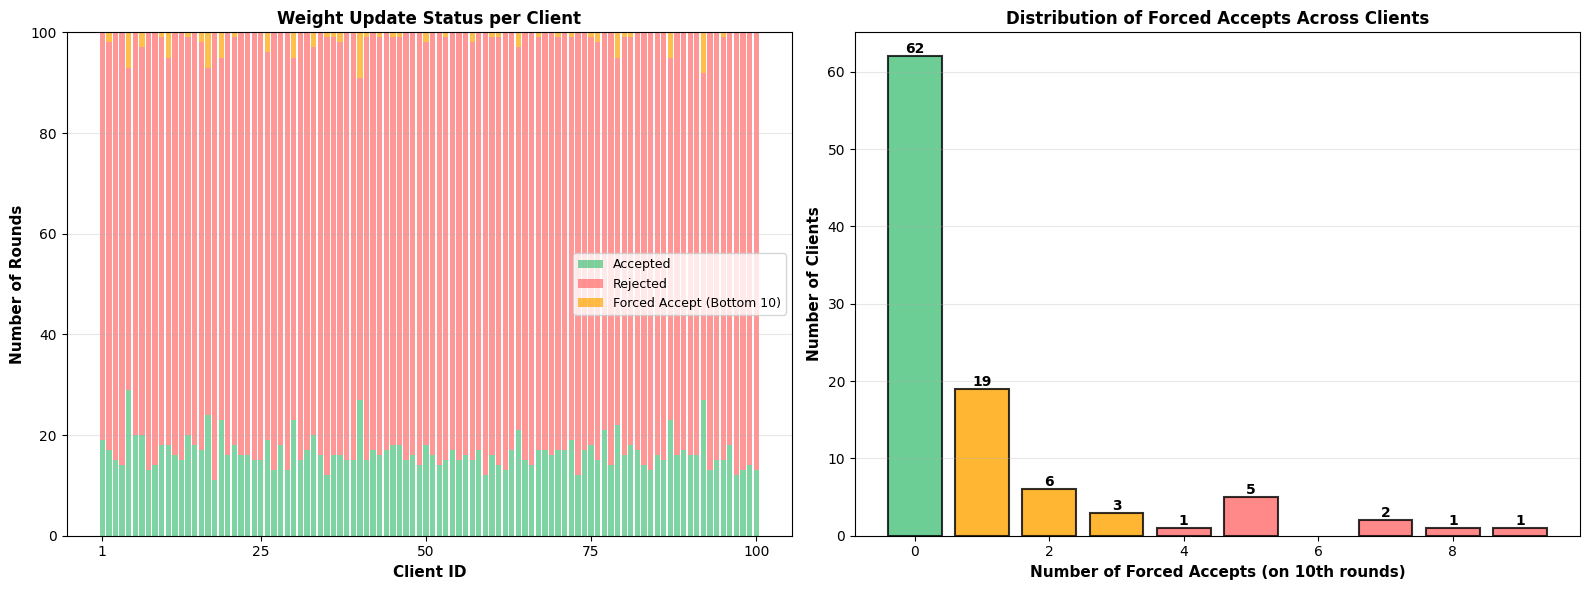


ALL VISUALIZATIONS COMPLETE!


In [ ]:
# Plot 4: Weight Update Statistics
print("Creating weight update statistics plot...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 4a: Rejections, Acceptances, and Forced Accepts per client
client_ids = [i+1 for i in range(NUM_CLIENTS)]
x_pos = np.arange(NUM_CLIENTS)

ax1.bar(x_pos, total_acceptances_per_client, color='#47C27B', alpha=0.7, label='Accepted')
ax1.bar(x_pos, total_rejections_per_client, bottom=total_acceptances_per_client, 
       color='#FF6B6B', alpha=0.7, label='Rejected')
forced_accepts_bottom = [total_acceptances_per_client[i] + total_rejections_per_client[i] 
                        for i in range(NUM_CLIENTS)]
ax1.bar(x_pos, total_forced_accepts_per_client, bottom=forced_accepts_bottom, 
       color='#FFA500', alpha=0.7, label='Forced Accept (Bottom 10)')

ax1.set_xlabel('Client ID', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Rounds', fontsize=11, fontweight='bold')
ax1.set_title('Weight Update Status per Client', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xticks([0, 24, 49, 74, 99])
ax1.set_xticklabels(['1', '25', '50', '75', '100'])
ax1.grid(True, alpha=0.3, axis='y')

# Plot 4b: Distribution of forced accepts
forced_accept_counts = {}
for count in total_forced_accepts_per_client:
    forced_accept_counts[count] = forced_accept_counts.get(count, 0) + 1

counts = sorted(forced_accept_counts.keys())
frequencies = [forced_accept_counts[c] for c in counts]

colors = ['#47C27B' if c == 0 else '#FFA500' if c <= 3 else '#FF6B6B' for c in counts]

ax2.bar(counts, frequencies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Number of Forced Accepts (on 10th rounds)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Clients', fontsize=11, fontweight='bold')
ax2.set_title('Distribution of Forced Accepts Across Clients', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (count, freq) in enumerate(zip(counts, frequencies)):
    ax2.text(count, freq, str(freq), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
stats_plot_path = os.path.join(RESULTS_DIR, 'weight_statistics_bottom10_force_accept.png')
plt.savefig(stats_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {stats_plot_path}")
plt.show()

print("\n" + "="*60)
print("ALL VISUALIZATIONS COMPLETE!")
print("="*60)

## Save Results

In [ ]:
# Save all results to a file
results_file = os.path.join(RESULTS_DIR, 'final_results_bottom10_force_accept.txt')

with open(results_file, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("FEDERATED LEARNING - BOTTOM 10 FORCE ACCEPT STRATEGY\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("Configuration:\n")
    f.write(f"  Number of Clients: {NUM_CLIENTS}\n")
    f.write(f"  Communication Rounds: {NUM_ROUNDS}\n")
    f.write(f"  Local Epochs per Round: {LOCAL_EPOCHS}\n")
    f.write(f"  Batch Size: {BATCH_SIZE}\n")
    f.write(f"  Bottom Clients (forced accept): {NUM_BOTTOM_CLIENTS}\n\n")
    
    f.write("Final Results:\n")
    f.write(f"  Average Final Training Accuracy: {avg_final_train:.2f}%\n")
    f.write(f"  Average Final Test Accuracy: {avg_final_test:.2f}%\n")
    f.write(f"  Training Accuracy Range: [{np.min(final_train_accs):.2f}%, {np.max(final_train_accs):.2f}%]\n")
    f.write(f"  Test Accuracy Range: [{np.min(final_test_accs):.2f}%, {np.max(final_test_accs):.2f}%]\n\n")
    
    f.write("Weight Update Statistics:\n")
    f.write(f"  Total Acceptances: {sum(total_acceptances_per_client)}\n")
    f.write(f"  Total Rejections: {total_rejections}\n")
    f.write(f"  Total Forced Accepts: {total_forced_accepts}\n")
    f.write(f"  Number of 10th Rounds: {num_10th_rounds}\n")
    f.write(f"  Rejection Rate: {total_rejections / (sum(total_acceptances_per_client) + total_rejections + total_forced_accepts) * 100:.2f}%\n")
    f.write(f"  Avg Forced Accepts per Client: {avg_forced_accepts:.2f}\n\n")
    
    f.write(f"Final Bottom 10 Clients: {[c+1 for c in final_bottom_10]}\n\n")
    
    f.write("=" * 60 + "\n")

print(f"✓ Results saved to: {results_file}")
print("\n" + "="*60)
print("ALL TASKS COMPLETE!")
print("="*60)

✓ Results saved to: results_bottom10_force_accept\final_results_bottom10_force_accept.txt

ALL TASKS COMPLETE!
